# 📊 ALTAIR: Financial Forensics & Quantitative Analytics Playground

This notebook is a sandbox playground for testing the ALTAIR financial diagnostics pipeline (AVS Score, Altman Z, Sloan Ratio, Beneish M-Score, and sector models) **without any astrological inputs**.

It is fully structured to run both locally and in the cloud (e.g. Google Colab / Kaggle) by using fallback mock data if local files are missing, making it easy to share or test on GitHub.

### Cloud Setup (Optional: Google Colab)
If you are running this notebook in the cloud (Google Colab), uncomment and run the cell below to clone your repository and navigate into it:

In [1]:
# !git clone https://github.com/<your-github-username>/<your-repo-name>.git
# %cd <your-repo-name>

## 1. Setup & Path Configurations

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Add the project root to sys.path so we can import ALTAIR's engine components directly
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

print("Project Root Path:", project_root)
print("Current working directory:", os.getcwd())

Project Root Path: D:\ANTI-GRAVITY\ALTAIR BASE
Current working directory: D:\ANTI-GRAVITY\ALTAIR BASE\notebooks


## 2. Ingest Financial Data

We will attempt to load the local `GLOBAL_STRIKE_MAP_2026.csv` file containing the financial audit data of Indian and US large caps. If it does not exist (such as when running for the first time in a cloud container), we generate a mock dataset to allow testing of the modeling code.

In [3]:
strike_map_path = os.path.join(project_root, "data", "processed", "GLOBAL_STRIKE_MAP_2026.csv")

if os.path.exists(strike_map_path):
    df = pd.read_csv(strike_map_path)
    print(f"[+] Loaded local Strike Map with {len(df)} tickers.")
    display(df.head(10))
else:
    print("[!] Processed data file not found. Generating mock sandbox data for testing...")
    np.random.seed(42)
    tickers = ["AAPL", "TSLA", "MSFT", "AMZN", "NVDA", "RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS", "SBIN.NS", "ICICIBANK.NS", "ZOMATO.NS", "PAYTM.NS", "NYKAA.NS"]
    
    df = pd.DataFrame({
        "ticker": tickers,
        "market": ["US" if not t.endswith(".NS") else "IND" for t in tickers],
        "avs_score": np.random.uniform(10, 80, len(tickers)),
        "z_score": np.random.uniform(0.5, 5.0, len(tickers)),
        "leverage_ratio": np.random.uniform(0.1, 8.0, len(tickers)),
        "sloan_ratio": np.random.uniform(-0.15, 0.25, len(tickers)),
        "roic": np.random.uniform(-0.05, 0.40, len(tickers)),
        "m_score": np.random.uniform(-3.5, -1.0, len(tickers)),
        "f_score": np.random.randint(1, 9, len(tickers)),
        "short_float": np.random.uniform(0.5, 20.0, len(tickers)),
        "pe_ratio": np.random.uniform(10, 150, len(tickers)),
        "bailout_probability": np.random.choice([0, 5, 20, 80, 100], len(tickers)),
        "astra_strike_score": np.random.uniform(20, 95, len(tickers))
    })
    display(df)

[+] Loaded local Strike Map with 40 tickers.


,ticker,market,sector,sub_sector,avs_score,z_score,leverage_ratio,sloan_ratio,roic,m_score,f_score,short_float,pe_ratio,bailout_probability,astra_strike_score
0,BAJFINANCE.NS,IND,Headline,Large_Cap,43.33,NaN,10.00,0.1515,0.0000,-2.50,4,0.00,0.000000,30,51.33
1,TSLA,US,Headline,Large_Cap,28.55,18.26,1.43,-0.0795,0.0363,-2.51,5,0.02,370.690920,15,45.48
2,AMGN,US,Headline,Large_Cap,34.82,1.93,3.39,-0.0248,0.1233,-1.97,7,0.02,25.323345,30,45.37
3,AXISBANK.NS,IND,Headline,Large_Cap,34.53,NaN,10.00,0.0180,0.0000,-2.50,4,0.00,0.000000,30,45.17
4,KOTAKBANK.NS,IND,Headline,Large_Cap,33.33,NaN,10.00,-0.0224,0.0000,-2.50,4,0.00,0.000000,30,44.33
5,NVDA,US,Headline,Large_Cap,30.98,66.77,0.08,0.0839,0.6575,-1.09,3,0.01,31.069221,30,42.68
6,PYPL,US,Headline,Large_Cap,26.03,1.87,1.78,-0.0148,0.1759,-2.21,7,0.07,8.499083,30,39.22
7,TITAN.NS,IND,Headline,Large_Cap,24.40,7.83,3.88,-0.0085,0.1216,-2.08,5,0.00,0.000000,30,38.08
8,WIPRO.NS,IND,Headline,Large_Cap,21.30,4.12,1.19,-0.0122,0.1046,-2.03,3,0.00,0.000000,30,35.91
9,PEP,US,Headline,Large_Cap,20.12,3.42,2.82,-0.0358,0.1551,-2.23,4,0.03,18.076317,30,35.08


## 3. Interactive Testing of ALTAIR Financial Grading Engines

Here we test importing the actual core grading engines from our local python files and query `yfinance` to audit a specific stock live.

In [4]:
try:
    from src.engine.grade.ZScore import ZScoreEngine
    from src.engine.grade.SloanRatio import SloanRatioEngine
    from src.engine.grade.BeneishMScore import BeneishMScoreEngine
    from src.engine.hunter.SovereignAuditor import SovereignAuditor
    
    print("[+] Core Python engines imported successfully!")
    
    # Initialize shared Auditor
    auditor = SovereignAuditor()
    z_engine = ZScoreEngine(auditor)
    sloan_engine = SloanRatioEngine(auditor)
    beneish_engine = BeneishMScoreEngine(auditor)
    
    test_ticker = "AAPL"
    print(f"\n[*] Auditing {test_ticker} live via yfinance...")
    
    # Run calculations
    z, z_status = z_engine.calculate_altman_z(test_ticker)
    sloan = sloan_engine.calculate_sloan_ratio(test_ticker)
    m_score = beneish_engine.calculate_m_score(test_ticker)
    
    print(f"\nLive Results for {test_ticker}:")
    print(f"  Altman Z-Score:  {z:.4f} ({z_status})")
    print(f"  Sloan Ratio:     {sloan:.4f}")
    print(f"  Beneish M-Score: {m_score:.4f}")
    
except Exception as e:
    print("[!] Live audit skipped. (This is expected if running in the cloud without local source code or a network connection):", e)

[+] Core Python engines imported successfully!


[+] NSE Data Bridge: Session Revived (Cookie Captured).

[*] Auditing AAPL live via yfinance...
[*] Calculating Sovereign Z-Score for AAPL...


[*] Auditing Earnings Quality (Sloan Ratio) for AAPL...


    [+] Sloan Ratio: 0.0015 (STABLE)
[*] Auditing Manipulation (Beneish M-Score) for AAPL...
    [+] Beneish M-Score: -2.0 (REAL GROWTH)

Live Results for AAPL:
  Altman Z-Score:  11.7500 (Safe)
  Sloan Ratio:     0.0015
  Beneish M-Score: -2.0000


## 4. Train Explainable Boosting Machine (EBM) Glassbox Model

We will train an EBM model (`ExplainableBoostingRegressor` from the Microsoft `interpret` library) to model how a company's financial fragility features explain its Valuation (P/E ratio).

[*] Training EBM Glassbox model on 29 target samples...



=== EBM Global Feature Importances ===


,Feature,Importance
1,z_score,10.602580
0,avs_score,7.839404
4,roic,7.136551
5,m_score,5.230489
7,short_float,4.652106
2,leverage_ratio,3.330978
6,f_score,3.098162
3,sloan_ratio,2.186625
15,z_score & leverage_ratio,0.604274
20,z_score & short_float,0.597122


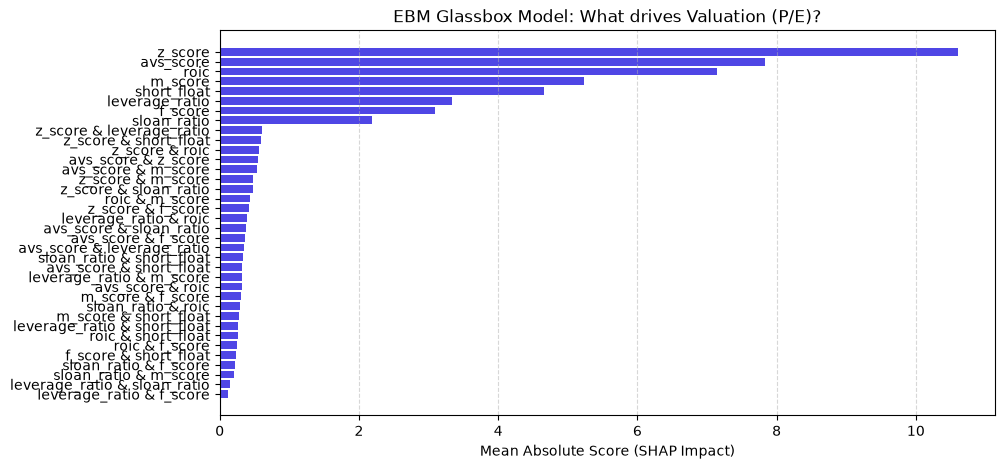

In [5]:
try:
    from interpret.glassbox import ExplainableBoostingRegressor
    
    # Specify our diagnostic features
    features = ["avs_score", "z_score", "leverage_ratio", "sloan_ratio", "roic", "m_score", "f_score", "short_float"]
    
    # Clean and load data
    model_df = df.dropna(subset=features + ["pe_ratio"])
    
    X = model_df[features]
    y = model_df["pe_ratio"]
    
    print(f"[*] Training EBM Glassbox model on {len(model_df)} target samples...")
    
    ebm = ExplainableBoostingRegressor(random_state=42)
    ebm.fit(X, y)
    
    # Extract global feature importances
    ebm_global = ebm.explain_global()
    
    importance_df = pd.DataFrame({
        "Feature": ebm_global.data()["names"],
        "Importance": ebm_global.data()["scores"]
    }).sort_values("Importance", ascending=False)
    
    print("\n=== EBM Global Feature Importances ===")
    display(importance_df)
    
    # Plot the results
    plt.figure(figsize=(10, 5))
    plt.barh(importance_df["Feature"], importance_df["Importance"], color="#4f46e5")
    plt.xlabel("Mean Absolute Score (SHAP Impact)")
    plt.title("EBM Glassbox Model: What drives Valuation (P/E)?")
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()
    
except ImportError:
    print("[!] 'interpret' library is not installed. Please run: pip install interpret")
except Exception as e:
    print("[!] Model training failed:", e)